# 세 배치의 분포와 수명 관계 비교

**1. 수명·충전 정책 분포 → 2. 같은 초기 cycle의 변수와 ΔQ(V) → 3. 배치별 열화 곡선과 수명 관계** 순서로 확인합니다. `notebooks/`를 실행 위치로 두고 셀을 위에서부터 실행하세요. 각 배치에서 저장한 네 파일을 읽으며, 이 노트북은 원본이나 processed 파일을 다시 저장하지 않습니다.

배치마다 `cell_id`가 반복되므로 모든 결합에는 `(batch, cell_id)`를 사용합니다. 수명 결측은 변수 분포 비교에 포함하고, 수명과의 관계를 계산할 때만 제외합니다. 그래프의 축 이름은 폰트 설정 없이 실행할 수 있도록 영어로 표기합니다.

In [16]:
# 세 배치를 같은 색과 순서로 표시해 그래프 사이의 비교를 쉽게 합니다.
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
from IPython.display import display

DATA_DIR = Path("../data/processed")
BATCHES = ["batch1", "batch2", "batch3"]
KEYS = ["batch", "cell_id"]
EARLY_CYCLES = [10, 100]
MEASUREMENTS = ["QDischarge", "IR", "Tavg", "Tmax", "Tmin", "chargetime"]
COLORS = dict(zip(BATCHES, sns.color_palette("colorblind", 3)))
sns.set_theme(style="whitegrid")
np.random.seed(0)

## 입력 데이터와 비교 기준 확인

셀·summary CSV의 ID가 연결되는지, 중복 cycle이 없는지, 공통 전압축이 같은지 먼저 확인합니다. Batch1의 summary cycle 1은 측정값이 모두 0인 placeholder이므로 그래프용 데이터에서만 제외합니다. Batch2·3의 실제 cycle 1과 내부저항 0값은 유지합니다.

Batch3의 `-newstructure` 접미사는 원본 정책 문자열에 보존하고 숫자 충전 조건은 따로 추출합니다. Batch2의 `VarCharge`는 두 단계 정책과 다른 유형이므로 First/Second C-rate와 Switch SOC를 임의로 채우지 않습니다.

In [17]:
# 파일명에서 batch를 붙여, 같은 cell_id를 가진 다른 배치의 셀이 섞이지 않게 합니다.
cell_frames, summary_frames, voltage_axes = [], [], {}
for batch_name in BATCHES:
    for suffix in ("cells.csv", "cycle_summary.csv", "cycle_profiles.npz", "vdlin.csv"):
        assert (DATA_DIR / f"{batch_name}_{suffix}").is_file(), f"누락 파일: {batch_name}_{suffix}"
    cell_frame = pd.read_csv(DATA_DIR / f"{batch_name}_cells.csv").assign(batch=batch_name)
    summary_frame = pd.read_csv(DATA_DIR / f"{batch_name}_cycle_summary.csv").assign(batch=batch_name)
    assert not cell_frame.duplicated(KEYS).any(), f"{batch_name}: 중복 셀 ID"
    assert not summary_frame.duplicated(KEYS + ["cycle"]).any(), f"{batch_name}: 중복 cycle"
    assert set(summary_frame["cell_id"]) == set(cell_frame["cell_id"])
    assert len(summary_frame.merge(cell_frame[KEYS], on=KEYS, validate="many_to_one")) == len(summary_frame)
    cell_frames.append(cell_frame)
    summary_frames.append(summary_frame)
    voltage_axes[batch_name] = pd.read_csv(DATA_DIR / f"{batch_name}_vdlin.csv")["Vdlin"].to_numpy()

cells = pd.concat(cell_frames, ignore_index=True)
summary = pd.concat(summary_frames, ignore_index=True)
voltage = voltage_axes[BATCHES[0]]
assert len(voltage) == 1000 and np.all(np.diff(voltage) < 0)
assert all(np.allclose(axis, voltage, rtol=0, atol=1e-12) for axis in voltage_axes.values())

# 두 단계 policy 부분만 분해하고, VarCharge의 숫자 변수는 결측으로 둡니다.
pattern = r"^(?P<first_c_rate>\d+(?:\.\d+)?)C\((?P<switch_soc>\d+(?:\.\d+)?)%\)-(?P<second_c_rate>\d+(?:\.\d+)?)C"
parsed = cells["policy"].str.extract(pattern).astype(float)
cells = pd.concat([cells, parsed], axis=1)
cells["policy_family"] = np.select(
    [parsed.notna().all(axis=1), cells["policy"].str.startswith("VarCharge", na=False)],
    ["Two-stage", "VarCharge"], default="Unparsed"
)
cells["protocol"] = cells["policy"].str.replace(r"-newstructure$", "", regex=True)
# 동일한 숫자 조건을 같은 이름으로 묶되, 원본 policy 컬럼은 유지합니다.
regular = cells["policy_family"].eq("Two-stage")
cells.loc[regular, "protocol"] = cells.loc[regular].apply(
    lambda row: f"{row.first_c_rate:g}C({row.switch_soc:g}%)-{row.second_c_rate:g}C", axis=1
)

summary_measurements = ["IR", "QCharge", "QDischarge", "Tavg", "Tmax", "Tmin", "chargetime"]
placeholder = summary["cycle"].eq(1) & summary[summary_measurements].eq(0).all(axis=1)
summary_for_eda = summary.loc[~placeholder].copy()
quality = cells.groupby("batch").agg(
    cells=("cell_id", "size"), known_life=("cycle_life", "count"),
    two_stage_policies=("policy_family", lambda x: x.eq("Two-stage").sum())
).reindex(BATCHES)
quality["missing_life"] = quality["cells"] - quality["known_life"]
quality["summary_rows"] = summary.groupby("batch").size()
quality["placeholder_rows"] = summary.loc[placeholder].groupby("batch").size().reindex(BATCHES, fill_value=0)
display(quality)
display(pd.crosstab(cells["batch"], cells["policy_family"]).reindex(BATCHES))
if cells["policy_family"].eq("Unparsed").any():
    display(cells.loc[cells["policy_family"].eq("Unparsed"), KEYS + ["policy"]])

,cells,known_life,two_stage_policies,missing_life,summary_rows,placeholder_rows
batch,,,,,,
batch1,46,46,46,0,38811,46
batch2,47,39,43,8,26904,0
batch3,46,44,46,2,51007,0


policy_family,Two-stage,VarCharge
batch,,
batch1,46,0
batch2,43,4
batch3,46,0


## 1. 배치별 수명·충전 정책 분포

먼저 수명 분포의 위치와 폭, 장수명·단수명 비율, 충전 조건의 차이를 확인합니다. `cycle_life < 500`을 단수명, `cycle_life > 1000`을 장수명으로 정의하고, **비율의 분모는 수명이 알려진 셀 수**로 잡습니다. 수명 결측 수는 위의 품질 표에 별도로 표시했습니다.

,count,mean,std,min,25%,50%,75%,max
batch,,,,,,,,
batch1,46.0,844.717391,184.629198,534.0,703.25,858.5,914.25,1227.0
batch2,39.0,565.743590,222.201629,392.0,439.50,472.0,508.50,1186.0
batch3,44.0,1059.659091,313.869692,541.0,828.00,1005.5,1155.25,1935.0


life_group,Short (<500),Middle (500-1000),Long (>1000)
batch,,,
batch1,0,36,10
batch2,28,8,3
batch3,0,21,23


ratio_percent,Short (<500),Middle (500-1000),Long (>1000)
batch,,,
batch1,0.0,78.3,21.7
batch2,71.8,20.5,7.7
batch3,0.0,47.7,52.3


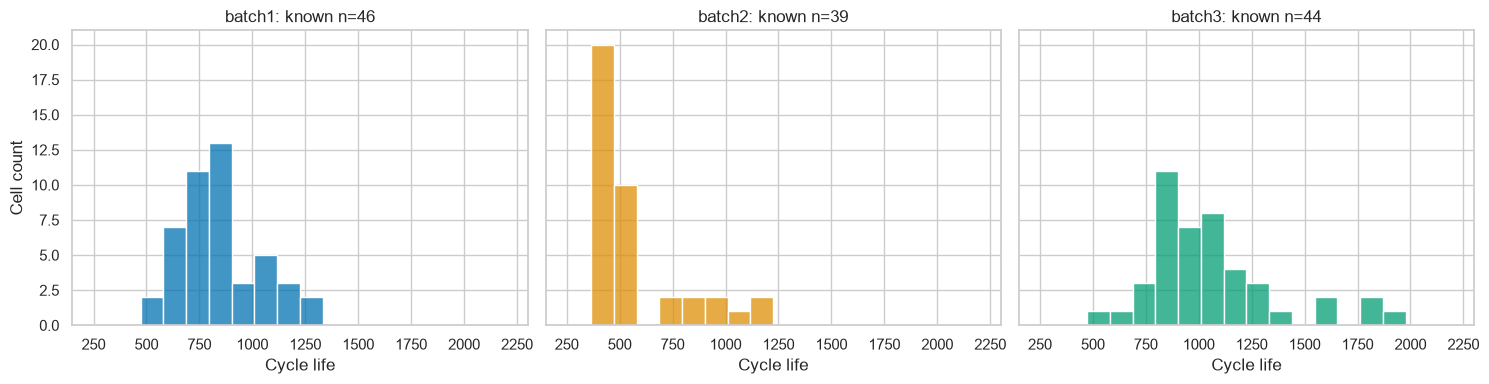

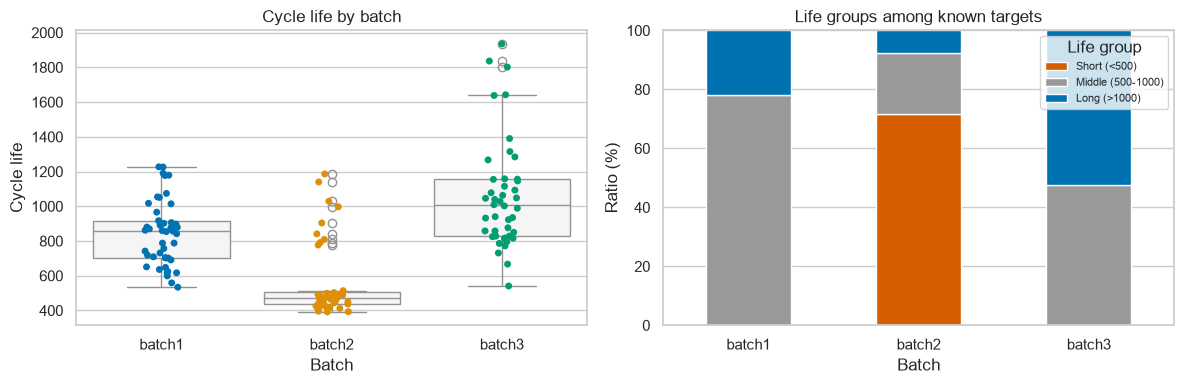

In [18]:
# 공통 구간과 bin을 사용해 배치마다 히스토그램 모양이 달라지는 이유를 비교합니다.
LIFE_GROUPS = ["Short (<500)", "Middle (500-1000)", "Long (>1000)", "Unknown"]
cells["life_group"] = np.select(
    [cells["cycle_life"].isna(), cells["cycle_life"] < 500, cells["cycle_life"] > 1000],
    ["Unknown", LIFE_GROUPS[0], LIFE_GROUPS[2]], default=LIFE_GROUPS[1]
)
known_life = cells.loc[cells["cycle_life"].notna()].copy()
display(known_life.groupby("batch")["cycle_life"].describe().reindex(BATCHES))
life_counts = pd.crosstab(known_life["batch"], known_life["life_group"]).reindex(
    index=BATCHES, columns=LIFE_GROUPS[:3], fill_value=0
)
life_ratio = life_counts.div(life_counts.sum(axis=1), axis=0).mul(100)
display(life_counts.rename_axis(columns="life_group"))
display(life_ratio.round(1).rename_axis(columns="ratio_percent"))

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True, sharey=True)
bins = np.linspace(150, 2300, 21)
for ax, batch_name in zip(axes, BATCHES):
    data = known_life.loc[known_life["batch"].eq(batch_name)]
    sns.histplot(data=data, x="cycle_life", bins=bins, color=COLORS[batch_name], ax=ax)
    ax.set(title=f"{batch_name}: known n={len(data)}", xlabel="Cycle life", ylabel="Cell count")
    ax.set_xlim(150, 2300)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=known_life, x="batch", y="cycle_life", order=BATCHES, color="whitesmoke", ax=axes[0])
sns.stripplot(data=known_life, x="batch", y="cycle_life", order=BATCHES, hue="batch", palette=COLORS, legend=False, ax=axes[0])
axes[0].set(title="Cycle life by batch", xlabel="Batch", ylabel="Cycle life")
life_ratio.plot.bar(stacked=True, ax=axes[1], color=["#D55E00", "#999999", "#0072B2"], rot=0)
axes[1].set(title="Life groups among known targets", xlabel="Batch", ylabel="Ratio (%)", ylim=(0, 100))
axes[1].legend(title="Life group", fontsize=8)
plt.tight_layout()
plt.show()

,batch,policy_family,protocol,n_cells
0,batch1,Two-stage,3.6C(80%)-3.6C,3
1,batch1,Two-stage,4.4C(80%)-4.4C,1
2,batch1,Two-stage,4.8C(80%)-4.8C,2
3,batch1,Two-stage,4C(80%)-4C,2
4,batch1,Two-stage,5.4C(40%)-3.6C,2
5,batch1,Two-stage,5.4C(50%)-3.6C,2
6,batch1,Two-stage,5.4C(50%)-3C,2
7,batch1,Two-stage,5.4C(60%)-3.6C,2
8,batch1,Two-stage,5.4C(60%)-3C,2
9,batch1,Two-stage,5.4C(70%)-3C,2


first_c_rate                  switch_soc                     \
              count  min median  max      count   min median   max   
batch                                                                
batch1           46  3.6    6.0  8.0         46  15.0   50.0  80.0   
batch2           43  3.6    5.2  6.0         43   9.0   58.0  80.0   
batch3           46  3.7    5.3  5.9         46  15.0   54.0  80.0   

       second_c_rate                   
               count  min median  max  
batch                                  
batch1            46  3.0    3.6  5.4  
batch2            43  3.0    4.5  6.0  
batch3            46  3.1    4.3  5.9

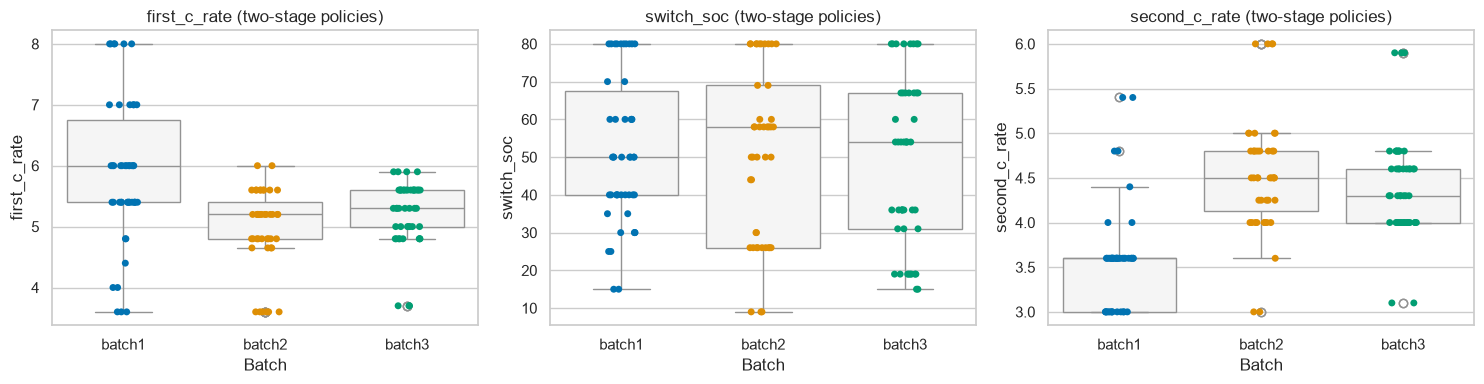

In [19]:
# 동일한 충전 변수라도 배치별 적용 범위가 다르면 수명 비교의 조건이 달라집니다.
policy_variables = ["first_c_rate", "switch_soc", "second_c_rate"]
policy_counts = cells.groupby(["batch", "policy_family", "protocol"]).size().rename("n_cells").reset_index()
display(policy_counts)
display(cells.groupby("batch")[policy_variables].agg(["count", "min", "median", "max"]).reindex(BATCHES))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, variable in zip(axes, policy_variables):
    sns.boxplot(data=cells, x="batch", y=variable, order=BATCHES, color="whitesmoke", ax=ax)
    sns.stripplot(data=cells, x="batch", y=variable, order=BATCHES, hue="batch", palette=COLORS, legend=False, ax=ax)
    ax.set(title=f"{variable} (two-stage policies)", xlabel="Batch", ylabel=variable)
plt.tight_layout()
plt.show()

## 2. 같은 초기 cycle에서 변수 비교

전체 summary 행을 합쳐 분포를 비교하면 오래 측정된 셀이 더 큰 비중을 차지합니다. 따라서 **셀 하나를 관측값 하나로 두고 cycle 10·100의 값을 비교**합니다. 변화량은 `100번 값 − 10번 값`입니다. 해당 cycle이 없거나 측정값이 결측인 셀은 그 변수 비교에서 제외하며, 사용 가능한 셀 수를 표로 확인합니다.

In [20]:
# 초기 cycle의 측정값을 셀당 한 행으로 만들어 이후 비교의 표본 단위를 통일합니다.
early_summary = summary_for_eda.loc[summary_for_eda["cycle"].isin(EARLY_CYCLES)]
early_wide = early_summary.pivot(index=KEYS, columns="cycle", values=MEASUREMENTS)
early_wide = early_wide.reindex(columns=pd.MultiIndex.from_product([MEASUREMENTS, EARLY_CYCLES]))
early_wide.columns = [f"{variable}_{cycle}" for variable, cycle in early_wide.columns]
features = cells.merge(early_wide.reset_index(), on=KEYS, how="left", validate="one_to_one")
features["delta_q_discharge"] = features["QDischarge_100"] - features["QDischarge_10"]
features["delta_ir"] = features["IR_100"] - features["IR_10"]
features["delta_tavg"] = features["Tavg_100"] - features["Tavg_10"]
assert len(features) == len(cells) and not features.duplicated(KEYS).any()
display(early_summary.groupby(["batch", "cycle"]).size().unstack().reindex(BATCHES))
display(features[KEYS + ["cycle_life", "QDischarge_10", "QDischarge_100", "delta_q_discharge"]].head())

cycle,10,100
batch,,
batch1,46,46
batch2,47,47
batch3,46,46


,batch,cell_id,cycle_life,QDischarge_10,QDischarge_100,delta_q_discharge
0,batch1,1,1190.0,1.074537,1.075913,0.001375
1,batch1,2,1179.0,1.079777,1.080630,0.000853
2,batch1,3,1177.0,1.083782,1.084940,0.001159
3,batch1,4,1226.0,1.084308,1.084750,0.000442
4,batch1,5,1227.0,1.081954,1.082646,0.000692


### 初期 ΔQ(V) 추출

`ΔQ(V) = Qdlin(cycle 100) − Qdlin(cycle 10)`을 계산합니다. summary의 `QDischarge` 변화는 숫자 하나이고, 여기서의 ΔQ(V)는 공통 전압축의 1000개 점으로 이루어진 곡선입니다. NPZ의 행 번호를 cycle 번호로 추정하지 않고 저장된 `cell_N_cycle` 배열에서 위치를 찾습니다. Batch1·2·3 모두 같은 기준을 사용합니다.

In [21]:
# 큰 NPZ는 셀별 Qdlin 배열만 읽고, 비교에 필요한 ΔQ(V) 곡선만 메모리에 남깁니다.
delta_profiles, profile_feature_rows = {}, []
for batch_name in BATCHES:
    with np.load(DATA_DIR / f"{batch_name}_cycle_profiles.npz") as archive:
        for cell_id in cells.loc[cells["batch"].eq(batch_name), "cell_id"]:
            cycle = archive[f"cell_{cell_id}_cycle"]
            assert np.all(np.diff(cycle) > 0), (batch_name, cell_id, "profile cycle 순서")
            idx_10 = np.flatnonzero(cycle == 10)
            idx_100 = np.flatnonzero(cycle == 100)
            if len(idx_10) != 1 or len(idx_100) != 1:
                continue  # 원래 셀은 features에 유지하고 ΔQ(V)만 결측으로 남깁니다.
            qdlin = archive[f"cell_{cell_id}_qdlin"]
            assert qdlin.shape == (len(cycle), len(voltage)), (batch_name, cell_id, "profile 축")
            delta = qdlin[idx_100[0]] - qdlin[idx_10[0]]
            if not np.isfinite(delta).all():
                continue
            delta_profiles[(batch_name, cell_id)] = delta
            variance = float(np.var(delta))
            profile_feature_rows.append({
                "batch": batch_name, "cell_id": cell_id,
                "dqv_mean": float(np.mean(delta)), "dqv_std": float(np.std(delta)),
                "dqv_min": float(np.min(delta)), "dqv_max": float(np.max(delta)),
                "dqv_var": variance, "log10_dqv_var": np.log10(variance) if variance > 0 else np.nan,
            })
            del qdlin
assert profile_feature_rows, "cycle 10·100의 유효한 profile이 없습니다."
features = features.merge(pd.DataFrame(profile_feature_rows), on=KEYS, how="left", validate="one_to_one")
assert len(features) == len(cells) and not features.duplicated(KEYS).any()
availability_fields = ["cycle_life", "first_c_rate", "QDischarge_10", "QDischarge_100", "delta_q_discharge", "delta_ir", "delta_tavg", "dqv_mean", "log10_dqv_var"]
display(features.groupby("batch")[availability_fields].count().reindex(BATCHES).rename_axis(columns="available_cells"))

available_cells,cycle_life,first_c_rate,QDischarge_10,QDischarge_100,delta_q_discharge,delta_ir,delta_tavg,dqv_mean,log10_dqv_var
batch,,,,,,,,,
batch1,46,46,46,46,46,46,46,46,46
batch2,39,43,47,47,47,47,47,47,47
batch3,44,46,46,46,46,46,46,46,46


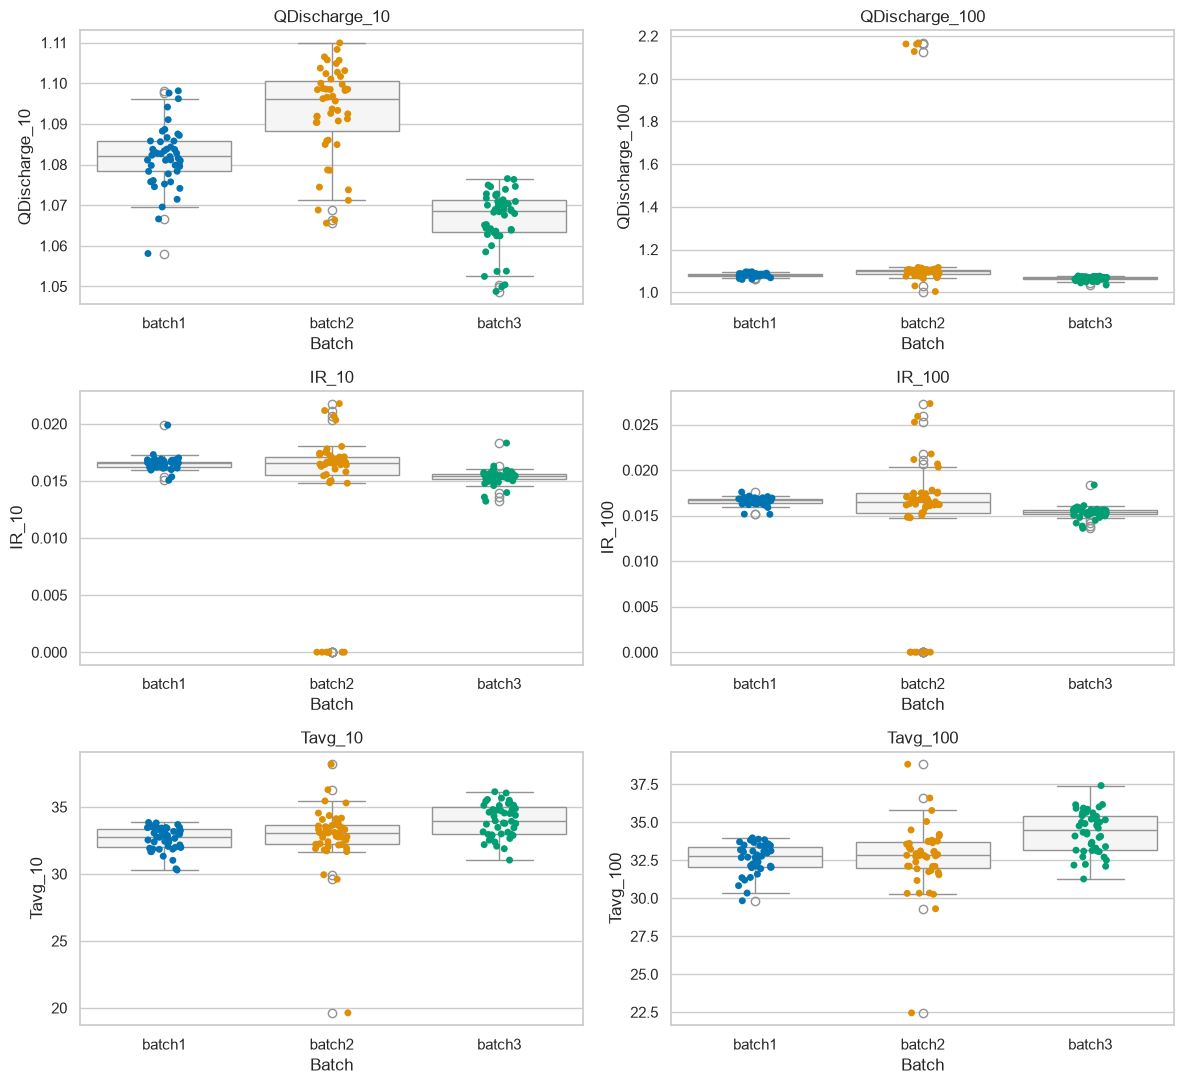

delta_q_discharge                               delta_ir            \
                   count    median       min       max    count    median   
batch                                                                       
batch1                46 -0.000903 -0.014476  0.002100       46  0.000153   
batch2                47  0.000254 -0.062894  1.082484       47  0.000000   
batch3                46 -0.001247 -0.018674  0.000391       46  0.000023   

                           delta_tavg                                \
             min       max      count    median       min       max   
batch                                                                 
batch1 -0.003995  0.000284         46  0.064092 -0.502241  1.061994   
batch2 -0.000507  0.010226         47 -0.092040 -2.771192  2.823357   
batch3 -0.000483  0.000384         46  0.283282  0.035142  1.269682   

       log10_dqv_var                                
               count    median       min       max  
batch                                               
batch1            46 -3.851160 -5.014861 -3.350338  
batch2            47 -3.494881 -4.770611 -2.684918  
batch3            46 -4.198987 -5.098856 -3.451658

In [22]:
# 고정 cycle에서 용량·저항·온도를 비교해 배치별 초기 상태가 다른지 확인합니다.
initial_fields = ["QDischarge_10", "QDischarge_100", "IR_10", "IR_100", "Tavg_10", "Tavg_100"]
fig, axes = plt.subplots(3, 2, figsize=(12, 11))
for ax, variable in zip(axes.flat, initial_fields):
    sns.boxplot(data=features, x="batch", y=variable, order=BATCHES, color="whitesmoke", ax=ax)
    sns.stripplot(data=features, x="batch", y=variable, order=BATCHES, hue="batch", palette=COLORS, legend=False, ax=ax)
    ax.set(title=variable, xlabel="Batch", ylabel=variable)
plt.tight_layout()
plt.show()

display(features.groupby("batch")[["delta_q_discharge", "delta_ir", "delta_tavg", "log10_dqv_var"]].agg(["count", "median", "min", "max"]).reindex(BATCHES))

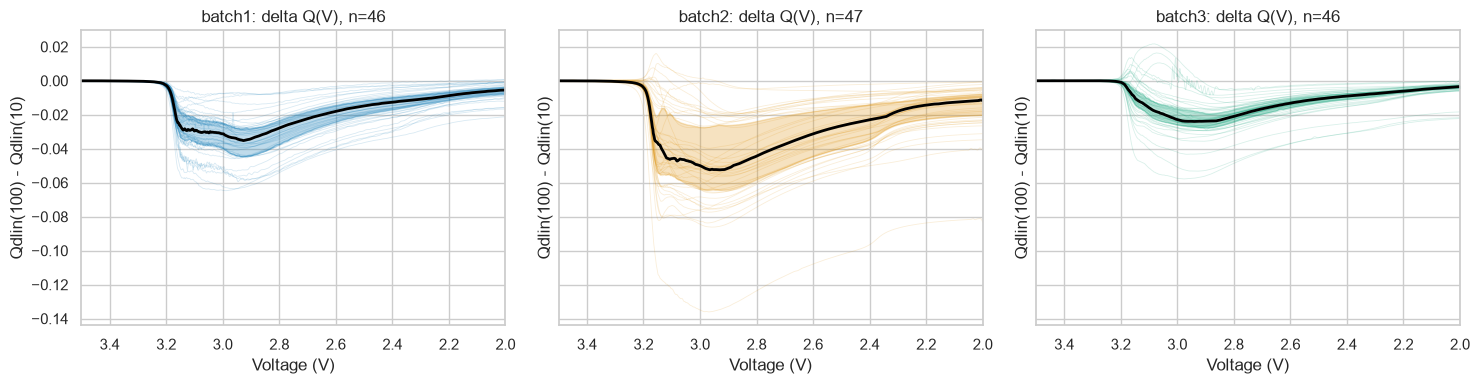

In [23]:
# 가는 선은 셀별 차이, 굵은 선은 중앙값, 음영은 25~75% 범위를 보여줍니다.
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True, sharey=True)
for ax, batch_name in zip(axes, BATCHES):
    profiles = [delta for (batch, cell_id), delta in delta_profiles.items() if batch == batch_name]
    if profiles:
        array = np.stack(profiles)
        ax.plot(voltage, array.T, color=COLORS[batch_name], alpha=0.15, linewidth=0.6)
        lower, median, upper = np.percentile(array, [25, 50, 75], axis=0)
        ax.fill_between(voltage, lower, upper, color=COLORS[batch_name], alpha=0.25)
        ax.plot(voltage, median, color="black", linewidth=2, label="Median")
        ax.set_title(f"{batch_name}: delta Q(V), n={len(profiles)}")
    else:
        ax.set_title(f"{batch_name}: no valid profiles")
    ax.set(xlabel="Voltage (V)", ylabel="Qdlin(100) - Qdlin(10)", xlim=(3.5, 2.0))
plt.tight_layout()
plt.show()

## 3. 배치별 열화 곡선과 수명 관계

열화 곡선은 원래 관측 기간 전체를 보여주고, 변수와 수명의 관계는 위에서 만든 **초기 cycle 특성만** 사용합니다. Batch2에는 `cycle_life` 이후까지 기록된 cycle이 있으므로 곡선 길이를 수명으로 해석하지 않습니다. 수명 결측 셀의 곡선도 표시하되 수명 관계 계산에서는 제외합니다.

정규화 곡선은 각 셀의 cycle 10 방전 용량을 기준으로 나눕니다. 위의 절대 용량 그래프는 원본 이상치를 포함하고, 아래 정규화 그래프는 0.7~1.15 범위를 확대해 열화 패턴을 봅니다. 확대 범위 밖의 값도 데이터에는 그대로 남습니다. 모든 배치에 같은 cycle 축을 사용합니다.

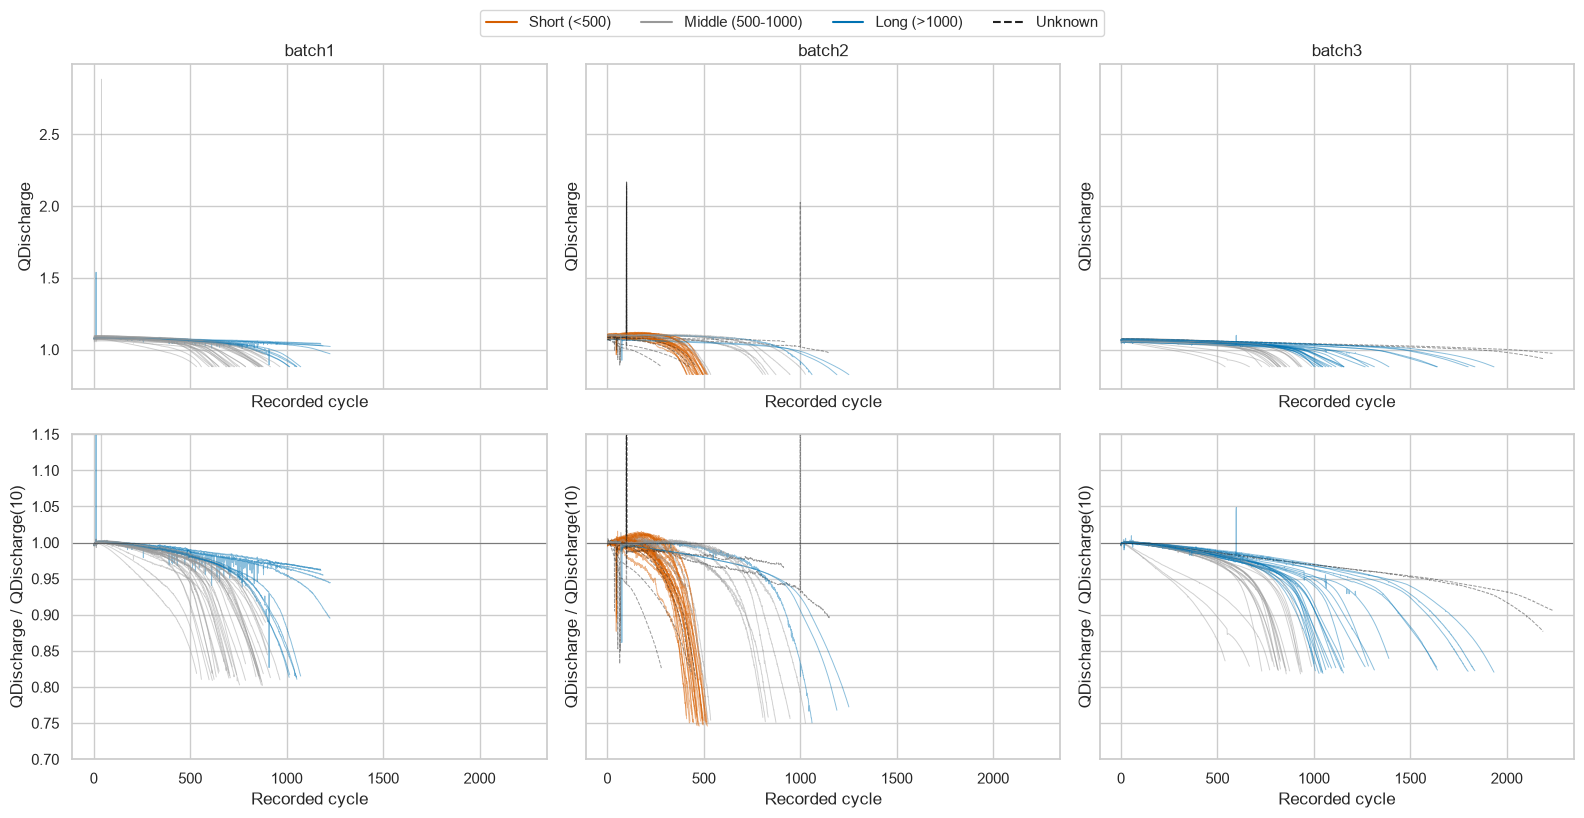

In [24]:
# 용량의 절대값과 cycle 10 기준 상대 변화를 함께 봅니다.
degradation = summary_for_eda.merge(
    features[KEYS + ["cycle_life", "life_group", "QDischarge_10"]], on=KEYS, validate="many_to_one"
)
baseline = degradation["QDischarge_10"].where(degradation["QDischarge_10"] > 0)
degradation["relative_q"] = degradation["QDischarge"] / baseline
GROUP_COLORS = {LIFE_GROUPS[0]: "#D55E00", LIFE_GROUPS[1]: "#999999", LIFE_GROUPS[2]: "#0072B2", "Unknown": "#222222"}
fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=True, sharey="row")
for col, batch_name in enumerate(BATCHES):
    batch_data = degradation.loc[degradation["batch"].eq(batch_name)]
    for cell_id, track in batch_data.groupby("cell_id"):
        track = track.sort_values("cycle")
        group = track["life_group"].iloc[0]
        style = "--" if group == "Unknown" else "-"
        axes[0, col].plot(track["cycle"], track["QDischarge"], color=GROUP_COLORS[group], linestyle=style, alpha=0.45, linewidth=0.7)
        axes[1, col].plot(track["cycle"], track["relative_q"], color=GROUP_COLORS[group], linestyle=style, alpha=0.45, linewidth=0.7)
    axes[0, col].set(title=batch_name, ylabel="QDischarge", xlabel="Recorded cycle")
    axes[1, col].set(ylabel="QDischarge / QDischarge(10)", xlabel="Recorded cycle")
    # 표시 범위만 확대해 이상치에 눌리지 않는 열화 패턴을 봅니다.
    axes[1, col].set_ylim(0.7, 1.15)
    axes[1, col].axhline(1, color="black", linewidth=0.8, alpha=0.4)
handles = [Line2D([0], [0], color=GROUP_COLORS[group], linestyle="--" if group == "Unknown" else "-", label=group) for group in LIFE_GROUPS]
fig.legend(handles=handles, loc="upper center", ncol=4, bbox_to_anchor=(0.5, 1.03))
plt.tight_layout()
plt.show()

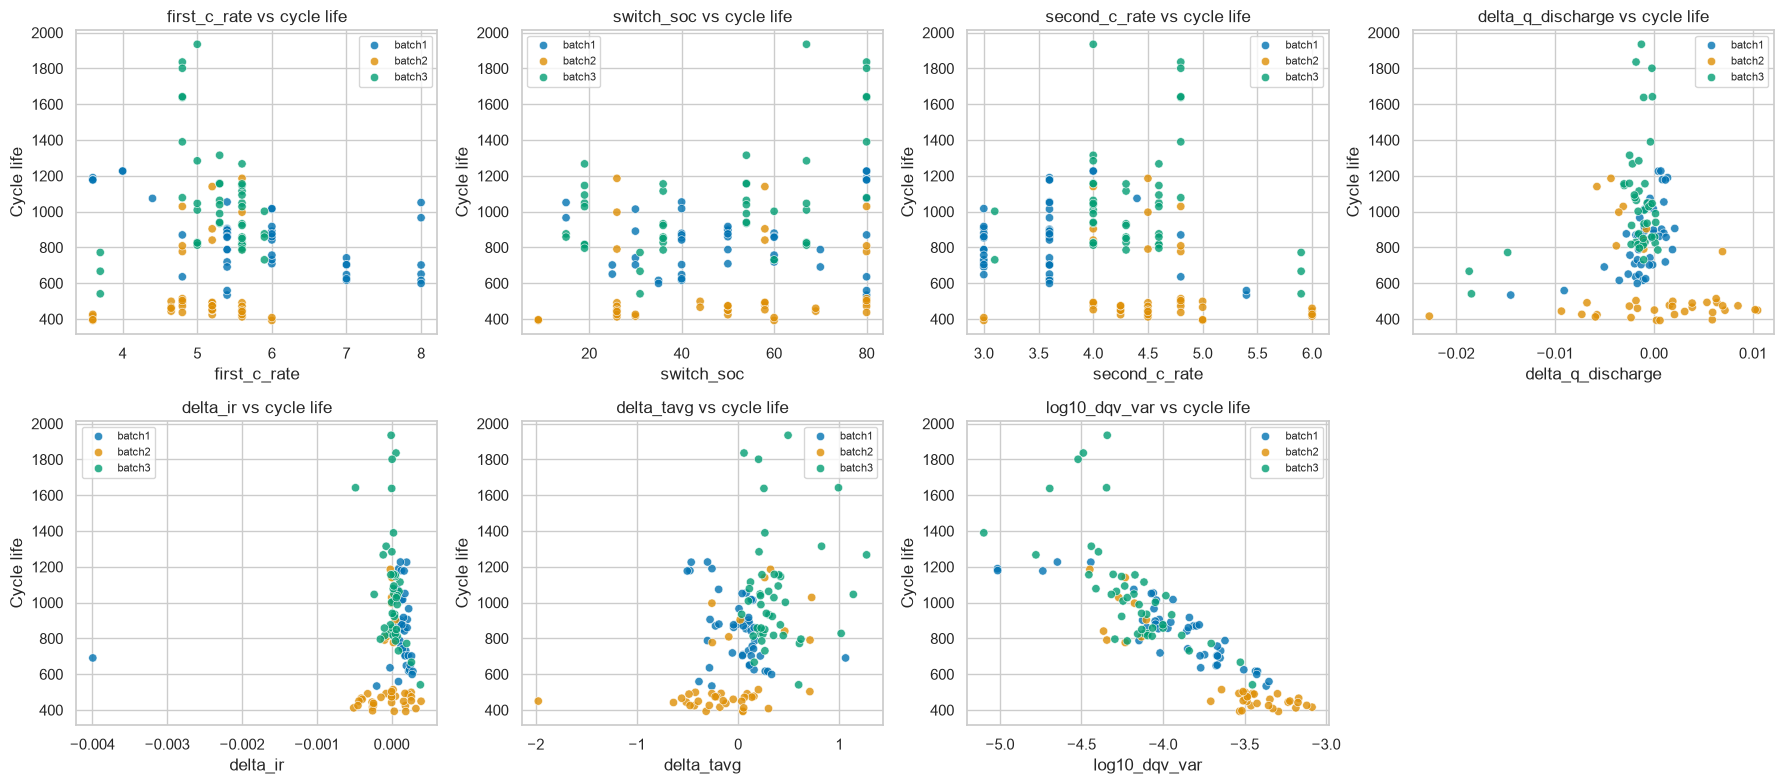

,batch,policy_family,protocol,n_cells,n_known_life,mean_life,median_life
0,batch1,Two-stage,3.6C(80%)-3.6C,3,3,1182.000000,1179.0
1,batch1,Two-stage,4.4C(80%)-4.4C,1,1,1074.000000,1074.0
2,batch1,Two-stage,4.8C(80%)-4.8C,2,2,753.000000,753.0
3,batch1,Two-stage,4C(80%)-4C,2,2,1226.500000,1226.5
4,batch1,Two-stage,5.4C(40%)-3.6C,2,2,966.500000,966.5
5,batch1,Two-stage,5.4C(50%)-3.6C,2,2,899.500000,899.5
6,batch1,Two-stage,5.4C(50%)-3C,2,2,847.000000,847.0
7,batch1,Two-stage,5.4C(60%)-3.6C,2,2,859.500000,859.5
8,batch1,Two-stage,5.4C(60%)-3C,2,2,799.500000,799.5
9,batch1,Two-stage,5.4C(70%)-3C,2,2,739.500000,739.5


In [25]:
# 셀당 한 점으로 그려 배치별 방향성과 동일 조건에서의 수명 편차를 확인합니다.
relation_fields = ["first_c_rate", "switch_soc", "second_c_rate", "delta_q_discharge", "delta_ir", "delta_tavg", "log10_dqv_var"]
relation_data = features.loc[features["cycle_life"].notna()].copy()
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, variable in zip(axes.flat, relation_fields):
    sns.scatterplot(data=relation_data, x=variable, y="cycle_life", hue="batch", hue_order=BATCHES, palette=COLORS, alpha=0.8, ax=ax)
    ax.set(title=f"{variable} vs cycle life", xlabel=variable, ylabel="Cycle life")
    ax.legend(fontsize=8)
for ax in list(axes.flat)[len(relation_fields):]:
    ax.set_visible(False)
plt.tight_layout()
plt.show()

# 정책별 평균은 표본 수와 함께 표시합니다. 작은 그룹의 순위만으로 정책 효과를 확정하지 않습니다.
policy_life_stats = cells.groupby(["batch", "policy_family", "protocol"]).agg(
    n_cells=("cell_id", "size"), n_known_life=("cycle_life", "count"),
    mean_life=("cycle_life", "mean"), median_life=("cycle_life", "median")
).reset_index()
display(policy_life_stats)

### 같은 변수가 배치마다 비슷한 관계를 보이는가?

Pearson은 선형 관계, Spearman은 값의 순서가 함께 변하는 경향을 요약합니다. 전체 배치를 합친 상관만 보면 충전 조건 구성의 차이가 섞일 수 있어 배치별로 계산합니다. 각 계수에 실제 사용한 셀 수 `n`을 함께 표시하며, 값이 일정하거나 표본이 너무 적으면 계수를 계산하지 않습니다.

,batch,feature,n,pearson,spearman
0,batch1,first_c_rate,46,-0.580,-0.483
1,batch1,switch_soc,46,0.235,0.185
2,batch1,second_c_rate,46,-0.096,0.047
3,batch1,delta_q_discharge,46,0.550,0.613
4,batch1,delta_ir,46,0.118,-0.240
5,batch1,delta_tavg,46,-0.438,-0.436
6,batch1,log10_dqv_var,46,-0.886,-0.871
7,batch2,first_c_rate,39,0.191,0.055
8,batch2,switch_soc,39,0.116,0.288
9,batch2,second_c_rate,39,-0.116,-0.119


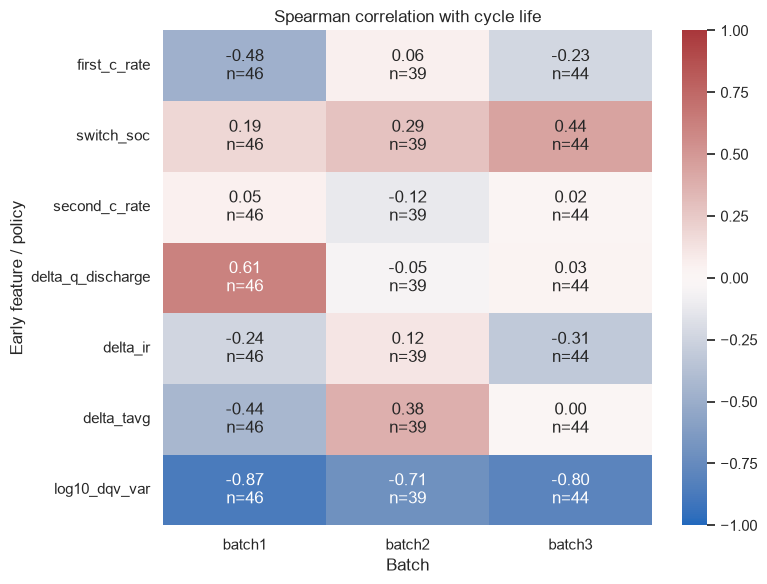

In [26]:
# 각 변수별 결측을 따로 제외해 계수의 실제 표본 수를 남깁니다.
correlation_rows = []
for batch_name in BATCHES:
    for variable in relation_fields:
        valid = relation_data.loc[relation_data["batch"].eq(batch_name), [variable, "cycle_life"]].dropna()
        enough = len(valid) >= 3 and valid[variable].nunique() > 1 and valid["cycle_life"].nunique() > 1
        correlation_rows.append({
            "batch": batch_name, "feature": variable, "n": len(valid),
            "pearson": valid[variable].corr(valid["cycle_life"], method="pearson") if enough else np.nan,
            "spearman": valid[variable].corr(valid["cycle_life"], method="spearman") if enough else np.nan,
        })
correlations = pd.DataFrame(correlation_rows)
display(correlations.round(3))
matrix = correlations.pivot(index="feature", columns="batch", values="spearman").reindex(index=relation_fields, columns=BATCHES)
sample_counts = correlations.pivot(index="feature", columns="batch", values="n").reindex(index=relation_fields, columns=BATCHES)
annotations = matrix.copy().astype(object)
for variable in relation_fields:
    for batch_name in BATCHES:
        value = matrix.loc[variable, batch_name]
        annotations.loc[variable, batch_name] = f"{value:.2f}\nn={sample_counts.loc[variable, batch_name]}" if pd.notna(value) else ""
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(matrix, annot=annotations, fmt="", cmap="vlag", center=0, vmin=-1, vmax=1, ax=ax)
ax.set(title="Spearman correlation with cycle life", xlabel="Batch", ylabel="Early feature / policy")
plt.tight_layout()
plt.show()

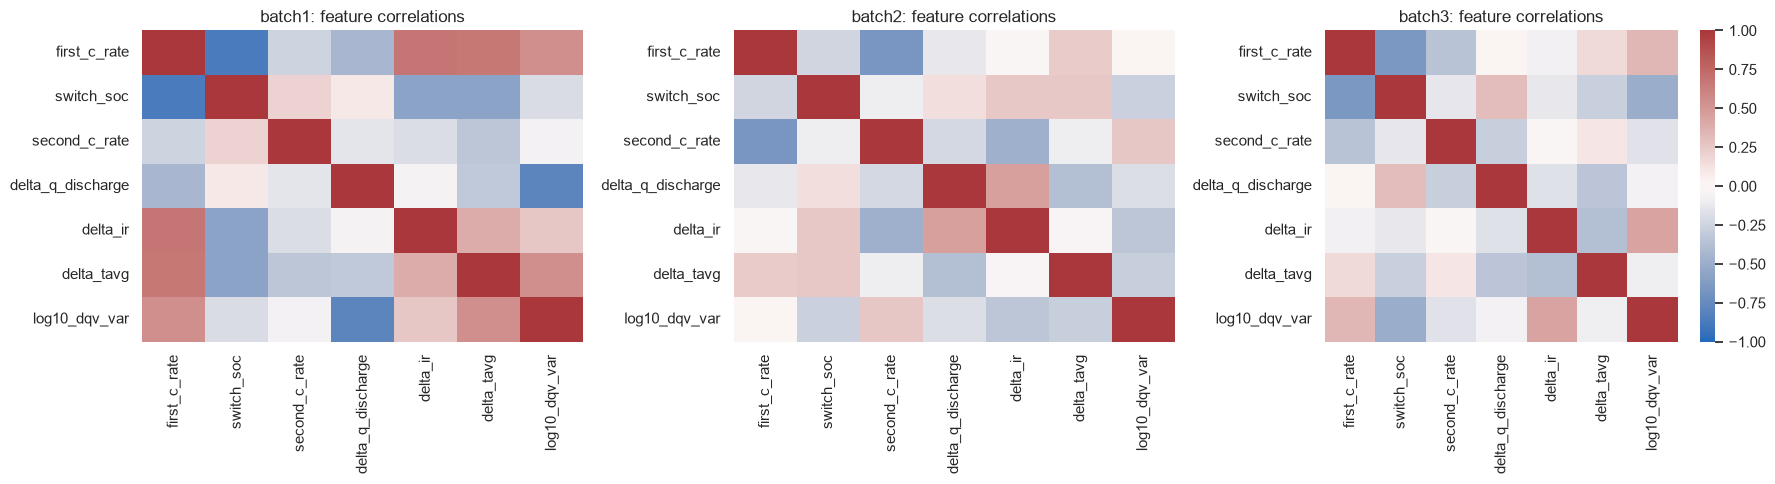

In [27]:
# 변수끼리 강하게 연관되어 있으면 수명과의 관계가 서로 겹치는 정보를 반영할 수 있습니다.
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, batch_name in zip(axes, BATCHES):
    matrix = features.loc[features["batch"].eq(batch_name), relation_fields].corr(method="spearman")
    sns.heatmap(matrix, cmap="vlag", center=0, vmin=-1, vmax=1, ax=ax, cbar=batch_name == BATCHES[-1])
    ax.set_title(f"{batch_name}: feature correlations")
plt.tight_layout()
plt.show()

## 결과를 보며 기록할 내용

1. 수명 분포 차이가 충전 정책의 범위·구성 차이와 함께 나타나는가?
2. cycle 10·100의 상태와 ΔQ(V) 분포가 배치별로 다른가? 몇 개의 극단적인 셀이 결과를 좌우하는가?
3. 수명과의 상관 방향이 세 배치에서 유지되는가? 서로 강하게 연결된 변수들이 있는가?

상관은 인과관계나 검증된 예측 성능을 의미하지 않습니다. 이후 모델링에서 `summary` 길이, 마지막 cycle, 전체 궤적의 통계처럼 최종 수명을 드러내는 값은 feature로 사용하지 않습니다. 이 노트북의 초기 특성은 cycle 100까지 관측한 뒤의 수명 분석을 위한 후보입니다. 수명 결측 셀의 의미와 별도 충전 유형은 추가 해석 대상으로 남겨둡니다.